# 02. Visualization and Comparison Notebook [FINAL]

This notebook compares the two final training runs directly:

- `YOLOv10n`: `results/mps_runs/yolov10n_main_mps_coslr_100ep_img640_b8`
- `YOLOv8n`: `results/mps_runs/yolov8n_main_mps_coslr_100ep_img640_b8`

If you do not see `[FINAL]` in the title, your IDE is still showing an old cached notebook.

In [1]:
import json
import os
import shutil
import time
from pathlib import Path

import cv2
import yaml
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from ultralytics import YOLO
from ultralytics import settings as ul_settings

plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

def find_project_root(start: Path | None = None) -> Path:
    start = start or Path.cwd()
    for candidate in [start, *start.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'notebooks').exists():
            return candidate
    return start

ROOT = find_project_root()
os.chdir(ROOT)

RUN_SUFFIX = 'mps_coslr_100ep_img640_b8'
RUN_V10 = ROOT / 'results' / 'mps_runs' / f'yolov10n_main_{RUN_SUFFIX}'
RUN_V8 = ROOT / 'results' / 'mps_runs' / f'yolov8n_main_{RUN_SUFFIX}'
RUNS = {'YOLOv10n': RUN_V10, 'YOLOv8n': RUN_V8}

for name, path in RUNS.items():
    if not path.exists():
        raise FileNotFoundError(f'Missing run for {name}: {path}')

ANALYSIS = ROOT / 'results' / 'mps_runs' / 'analysis_final'
FIGS = ANALYSIS / 'figures'
DATASETS_DIR = ROOT / 'data' / 'datasets'
for path in [ANALYSIS, FIGS, DATASETS_DIR]:
    path.mkdir(parents=True, exist_ok=True)

DEVICE = 'mps' if torch.backends.mps.is_available() else 'cpu'
ul_settings.update({'datasets_dir': str(DATASETS_DIR), 'runs_dir': str(ROOT / 'results' / 'mps_runs')})
WEIGHT_KIND = 'best'
DATA_YAML = 'VOC.yaml'
IMGSZ = 640
BATCH = 8

OFFICIAL_BENCH = {
    'YOLOv10n': {'params_m': 2.3, 'flops_g': 6.7, 'ap_val_ref_pct': 39.5, 'latency_ref_ms': 1.84, 'latencyf_ref_ms': 1.79},
    'YOLOv8n': {'params_m': 3.2, 'flops_g': 8.7, 'ap_val_ref_pct': 37.3, 'latency_ref_ms': 6.16, 'latencyf_ref_ms': 1.77},
}

print({'device': DEVICE, 'weight_kind': WEIGHT_KIND, 'run_v10': str(RUN_V10), 'run_v8': str(RUN_V8)})

{'device': 'mps', 'weight_kind': 'best', 'run_v10': '/Users/guillaumerabeau/deep-learning-paper-YOLOv10/results/mps_runs/yolov10n_main_mps_coslr_100ep_img640_b8', 'run_v8': '/Users/guillaumerabeau/deep-learning-paper-YOLOv10/results/mps_runs/yolov8n_main_mps_coslr_100ep_img640_b8'}


In [2]:
def save_json(obj, path: Path) -> None:
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(json.dumps(obj, indent=2, ensure_ascii=False), encoding='utf-8')

def load_json(path: Path):
    return json.loads(path.read_text(encoding='utf-8'))

def load_yaml(path: Path):
    return yaml.safe_load(path.read_text(encoding='utf-8'))

def load_train_csv(run_dir: Path) -> pd.DataFrame:
    df = pd.read_csv(run_dir / 'results.csv')
    df.columns = [c.strip() for c in df.columns]
    return df

def get_weights(run_dir: Path, kind: str = WEIGHT_KIND) -> str:
    path = run_dir / 'weights' / f'{kind}.pt'
    if not path.exists():
        raise FileNotFoundError(path)
    return str(path)

def maybe_set_end2end(model: YOLO, end2end):
    if end2end is None:
        return
    head = None
    if hasattr(model.model, 'model') and len(model.model.model):
        head = model.model.model[-1]
    if head is not None and hasattr(head, 'end2end'):
        head.end2end = end2end

def safe_float(x):
    return round(float(x), 6)

def summarize_metrics(metrics):
    names = metrics.names
    per_class = {}
    for idx, ap in enumerate(metrics.box.maps):
        class_name = names[idx] if not isinstance(names, dict) else names.get(idx, str(idx))
        per_class[class_name] = safe_float(ap)
    return {
        'map50': safe_float(metrics.box.map50),
        'map50_95': safe_float(metrics.box.map),
        'precision': safe_float(metrics.box.mp),
        'recall': safe_float(metrics.box.mr),
        'per_class_map50_95': per_class,
    }

def evaluate(weights: str, conf: float = 0.001, iou: float = 0.7, end2end=None) -> dict:
    model = YOLO(weights)
    maybe_set_end2end(model, end2end)
    metrics = model.val(data=DATA_YAML, imgsz=IMGSZ, batch=BATCH, conf=conf, iou=iou, split='val', device=DEVICE, workers=0, plots=False, verbose=False)
    return summarize_metrics(metrics)

def sync_device():
    if DEVICE == 'mps' and hasattr(torch, 'mps'):
        torch.mps.synchronize()
    elif DEVICE == 'cuda':
        torch.cuda.synchronize()

def measure_latency(weights: str, image_dir: Path, n_iter: int = 30, warmup: int = 10) -> dict:
    model = YOLO(weights)
    imgs = sorted(image_dir.glob('*.jpg'))[: warmup + n_iter]
    for path in imgs[:warmup]:
        model.predict(str(path), imgsz=IMGSZ, device=DEVICE, verbose=False)
    sync_device()
    t0 = time.perf_counter()
    for path in imgs[warmup:warmup + n_iter]:
        model.predict(str(path), imgsz=IMGSZ, device=DEVICE, verbose=False)
    sync_device()
    dt = time.perf_counter() - t0
    return {'ms': 1000 * dt / n_iter, 'fps': n_iter / dt, 'device': DEVICE}

def predict_boxes(weights: str, image_dir: Path, conf: float = 0.25, n: int = 100, end2end=None):
    model = YOLO(weights)
    maybe_set_end2end(model, end2end)
    counts, scores = [], []
    for path in sorted(image_dir.glob('*.jpg'))[:n]:
        result = model.predict(str(path), conf=conf, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
        counts.append(len(result.boxes))
        if len(result.boxes):
            scores.extend(result.boxes.conf.detach().cpu().numpy().tolist())
    return np.array(counts), np.array(scores)

def count_model_parameters(weights: str) -> float:
    model = YOLO(weights)
    total = sum(p.numel() for p in model.model.parameters())
    return total / 1e6

def checkpoint_size_mb(path: str | Path) -> float:
    return Path(path).stat().st_size / (1024 ** 2)

## Run Summary

This first table confirms that the notebook is reading the intended runs, checkpoints, and hyperparameters.
It is mainly a sanity check before interpreting the plots.

In [3]:
df_runs = pd.DataFrame([
    {
        'model': name,
        'run_dir': str(run_dir),
        'best': get_weights(run_dir, 'best'),
        'last': get_weights(run_dir, 'last'),
        **{k: load_yaml(run_dir / 'args.yaml')[k] for k in ['epochs', 'fraction', 'optimizer', 'batch', 'imgsz']},
    }
    for name, run_dir in RUNS.items()
])
df_runs

,model,run_dir,best,last,epochs,fraction,optimizer,batch,imgsz
0,YOLOv10n,/Users/guillaumerabeau/deep-learning-paper-YOL...,/Users/guillaumerabeau/deep-learning-paper-YOL...,/Users/guillaumerabeau/deep-learning-paper-YOL...,100,0.1,SGD,8,640
1,YOLOv8n,/Users/guillaumerabeau/deep-learning-paper-YOL...,/Users/guillaumerabeau/deep-learning-paper-YOL...,/Users/guillaumerabeau/deep-learning-paper-YOL...,100,0.1,SGD,8,640


## Learning Curves

These curves show how quickly both models improve during training.
A persistent gap here is usually stronger evidence than a single final checkpoint value.

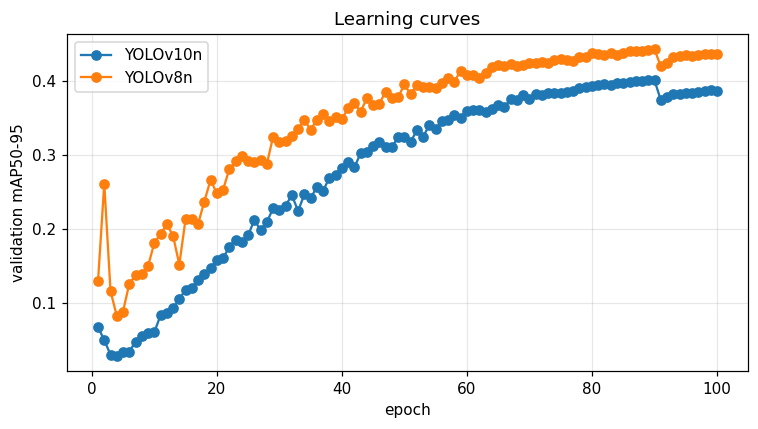

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
for model_name, run_dir in RUNS.items():
    df = load_train_csv(run_dir)
    ax.plot(df['epoch'], df['metrics/mAP50-95(B)'], marker='o', label=model_name)
ax.set_title('Learning curves')
ax.set_xlabel('epoch')
ax.set_ylabel('validation mAP50-95')
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / f'learning_curves_{WEIGHT_KIND}.png', dpi=150)
plt.show()

## Final Metrics

This is the main model comparison.
`mAP50-95` is the most important score because it is stricter than `mAP50` and reflects localization quality more reliably.

In [5]:
EVAL_CACHE = ANALYSIS / f'eval_summary_{WEIGHT_KIND}.json'
if EVAL_CACHE.exists():
    eval_results = load_json(EVAL_CACHE)
else:
    eval_results = {
        'YOLOv10n': evaluate(get_weights(RUN_V10)),
        'YOLOv8n': evaluate(get_weights(RUN_V8)),
    }
    save_json(eval_results, EVAL_CACHE)

df_eval = pd.DataFrame([
    {'model': name, **{k: vals[k] for k in ['map50', 'map50_95', 'precision', 'recall']}}
    for name, vals in eval_results.items()
])
df_eval

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.12.0 MPS (Apple M4)
YOLOv10n summary (fused): 102 layers, 2,269,068 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 239.7±58.0 MB/s, size: 86.0 KB)
val: Scanning /Users/guillaumerabeau/deep-learning-paper-YOLOv10/data/datasets/VOC/labels/test2007.cache... 4952 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4952/4952 1.3Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 619/619 11.4it/s 54.4s0.1ss
                   all       4952      12032      0.665      0.566      0.606      0.403
Speed: 0.2ms preprocess, 5.4ms inference, 0.0ms loss, 0.3ms postprocess per image
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.12.0 MPS (Apple M4)
Model summary (fused): 73 layers, 3,009,548 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 427.8±82.1 MB/s, size: 94.3 KB)
val: Scanning /Users/guillaumerabeau/deep-learni

,model,map50,map50_95,precision,recall
0,YOLOv10n,0.606310,0.402509,0.665489,0.566083
1,YOLOv8n,0.666753,0.443126,0.711347,0.618990


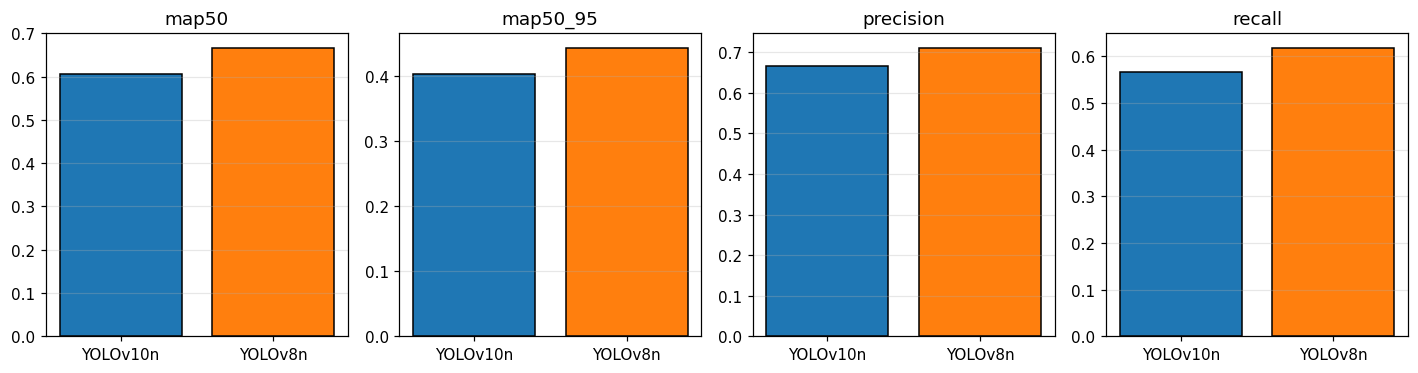

In [6]:
metrics = ['map50', 'map50_95', 'precision', 'recall']
fig, axes = plt.subplots(1, len(metrics), figsize=(13, 3.5))
for ax, metric in zip(axes, metrics):
    ax.bar(df_eval['model'], df_eval[metric], edgecolor='black', color=['C0', 'C1'])
    ax.set_title(metric)
    ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGS / f'final_metrics_{WEIGHT_KIND}.png', dpi=150)
plt.show()

## End-to-End vs Forced NMS

This is the paper-specific ablation.
It tests whether the native YOLOv10 end-to-end / NMS-free behavior stays competitive compared with the same checkpoint evaluated through a more classical NMS path.

In [7]:
ABL_CACHE = ANALYSIS / f'ablation_{WEIGHT_KIND}.json'
if ABL_CACHE.exists():
    df_ab = pd.DataFrame(load_json(ABL_CACHE))
else:
    rows = [
        {'model': 'YOLOv10 end2end', **evaluate(get_weights(RUN_V10), end2end=True)},
        {'model': 'YOLOv10 NMS forced', **evaluate(get_weights(RUN_V10), end2end=False)},
        {'model': 'YOLOv8', **evaluate(get_weights(RUN_V8))},
    ]
    save_json(rows, ABL_CACHE)
    df_ab = pd.DataFrame(rows)
df_ab

Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.12.0 MPS (Apple M4)
YOLOv10n summary (fused): 102 layers, 2,269,068 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 371.8±179.6 MB/s, size: 77.1 KB)
val: Scanning /Users/guillaumerabeau/deep-learning-paper-YOLOv10/data/datasets/VOC/labels/test2007.cache... 4952 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 4952/4952 5.2Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 619/619 11.1it/s 55.8s<0.1s
                   all       4952      12032      0.665      0.566      0.606      0.403
Speed: 0.3ms preprocess, 5.0ms inference, 0.0ms loss, 0.4ms postprocess per image
Ultralytics 8.4.52 🚀 Python-3.12.13 torch-2.12.0 MPS (Apple M4)
YOLOv10n summary (fused): 126 layers, 2,702,216 parameters, 0 gradients, 6.5 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 701.9±656.1 MB/s, size: 89.0 KB)
val: Scanning /Users/guillaumerabeau/deep-

,model,map50,map50_95,precision,recall,per_class_map50_95
0,YOLOv10 end2end,0.606310,0.402509,0.665489,0.566083,"{'aeroplane': 0.419502, 'bicycle': 0.498449, '..."
1,YOLOv10 NMS forced,0.647610,0.433878,0.703483,0.597765,"{'aeroplane': 0.465053, 'bicycle': 0.54094, 'b..."
2,YOLOv8,0.666753,0.443126,0.711347,0.618990,"{'aeroplane': 0.49915, 'bicycle': 0.531735, 'b..."


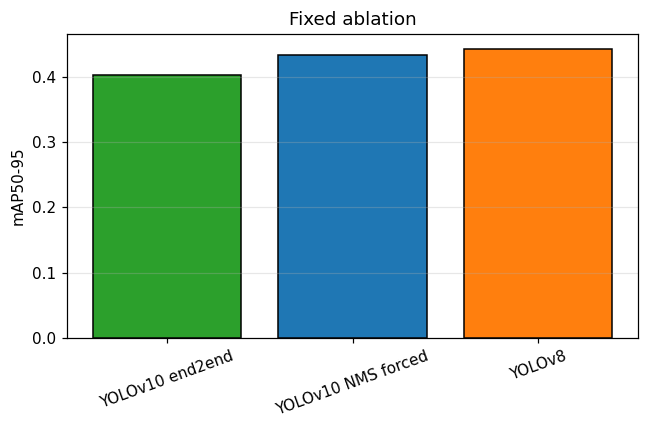

In [8]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(df_ab['model'], df_ab['map50_95'], edgecolor='black', color=['C2', 'C0', 'C1'])
ax.set_title('Fixed ablation')
ax.set_ylabel('mAP50-95')
ax.grid(True, alpha=0.3, axis='y')
ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.savefig(FIGS / f'ablation_{WEIGHT_KIND}.png', dpi=150)
plt.show()

## Sample Images for Latency and Qualitative Checks

A small validation subset is sufficient for local latency comparisons and qualitative inspection.
The goal here is consistency across models rather than official benchmark reporting.

In [9]:
VOC_PATH = DATASETS_DIR / 'VOC'
VAL_SAMPLE = ROOT / 'data' / 'voc_sample'
VAL_SAMPLE.mkdir(parents=True, exist_ok=True)
src = VOC_PATH / 'images' / 'test2007'
if src.exists() and len(list(VAL_SAMPLE.glob('*.jpg'))) < 120:
    for path in sorted(src.glob('*.jpg'))[:120]:
        target = VAL_SAMPLE / path.name
        if not target.exists():
            shutil.copy(path, target)
print({'voc_path_exists': VOC_PATH.exists(), 'sample_images': len(list(VAL_SAMPLE.glob('*.jpg')))})

{'voc_path_exists': True, 'sample_images': 120}


## Latency and Efficiency

This section combines accuracy and cost.
It helps answer whether any performance difference comes with a meaningful local runtime penalty.

In [10]:
LAT_CACHE = ANALYSIS / f'latency_{WEIGHT_KIND}.json'
if LAT_CACHE.exists():
    lat = load_json(LAT_CACHE)
else:
    lat = {
        'YOLOv10n': measure_latency(get_weights(RUN_V10), VAL_SAMPLE),
        'YOLOv8n': measure_latency(get_weights(RUN_V8), VAL_SAMPLE),
    }
    save_json(lat, LAT_CACHE)
df_lat = pd.DataFrame([{'model': k, **v} for k, v in lat.items()])
df_lat

,model,ms,fps,device
0,YOLOv10n,21.189324,47.193578,mps
1,YOLOv8n,19.000525,52.630125,mps


In [11]:
size_rows = []
for model_name, run_dir in RUNS.items():
    ref = OFFICIAL_BENCH[model_name]
    size_rows.append({
        'model': model_name,
        'Param.(M)': ref['params_m'],
        'FLOPs(G)': ref['flops_g'],
        'APval_ref(%)': ref['ap_val_ref_pct'],
        'Latency_ref(ms)': ref['latency_ref_ms'],
        'Latencyf_ref(ms)': ref['latencyf_ref_ms'],
        'APval_VOC(%)': 100 * eval_results[model_name]['map50_95'],
        'Latency_local(ms)': lat[model_name]['ms'],
        'Checkpoint_best(MB)': checkpoint_size_mb(get_weights(run_dir, 'best')),
        'Checkpoint_last(MB)': checkpoint_size_mb(get_weights(run_dir, 'last')),
        'Params_recounted(M)': count_model_parameters(get_weights(run_dir)),
    })
df_eff = pd.DataFrame(size_rows)
for col in df_eff.columns[1:]:
    df_eff[col] = df_eff[col].map(lambda x: round(float(x), 2))
df_eff

,model,Param.(M),FLOPs(G),APval_ref(%),Latency_ref(ms),Latencyf_ref(ms),APval_VOC(%),Latency_local(ms),Checkpoint_best(MB),Checkpoint_last(MB),Params_recounted(M)
0,YOLOv10n,2.3,6.7,39.5,1.84,1.79,40.25,21.19,5.48,5.48,2.71
1,YOLOv8n,3.2,8.7,37.3,6.16,1.77,44.31,19.00,5.95,5.95,3.01


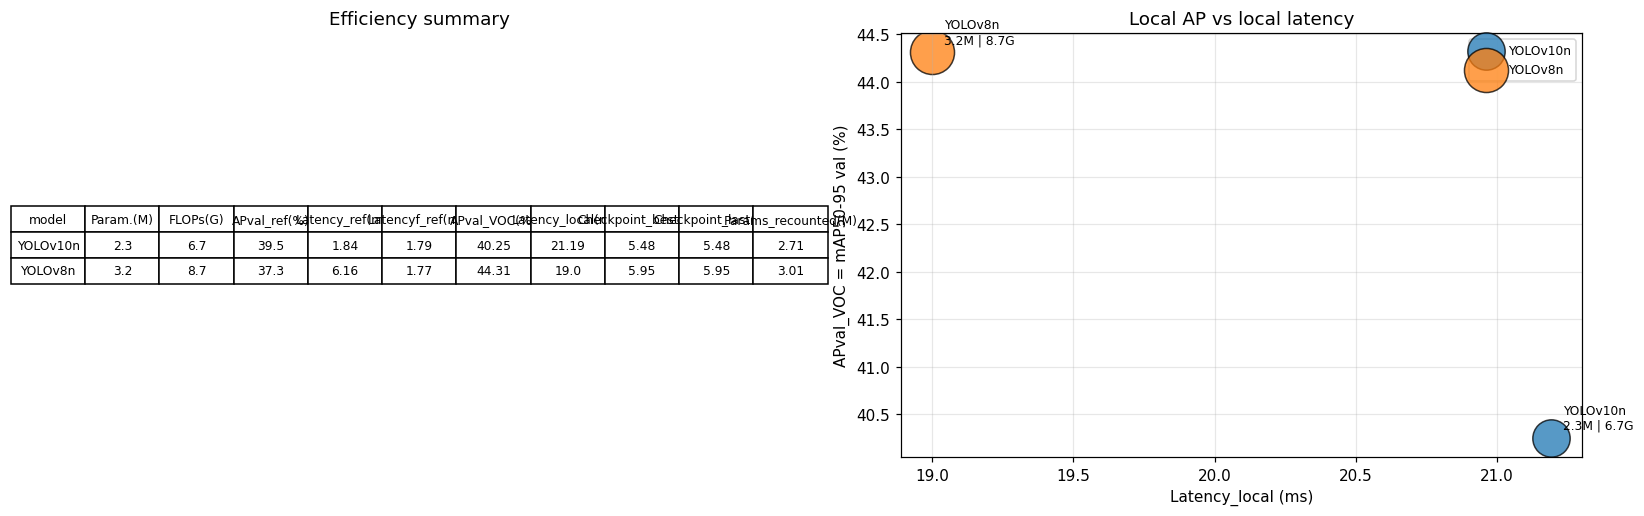

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.8))

axes[0].axis('off')
table = axes[0].table(cellText=df_eff.values, colLabels=df_eff.columns, loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1.2, 1.35)
axes[0].set_title('Efficiency summary')

for _, row in df_eff.iterrows():
    axes[1].scatter(row['Latency_local(ms)'], row['APval_VOC(%)'], s=row['Param.(M)'] * 260, alpha=0.75, edgecolors='black', label=row['model'])
    axes[1].annotate(
        f"{row['model']}\n{row['Param.(M)']:.1f}M | {row['FLOPs(G)']:.1f}G",
        (row['Latency_local(ms)'], row['APval_VOC(%)']),
        textcoords='offset points',
        xytext=(8, 6),
        fontsize=8,
    )

axes[1].set_title('Local AP vs local latency')
axes[1].set_xlabel('Latency_local (ms)')
axes[1].set_ylabel('APval_VOC = mAP50-95 val (%)')
axes[1].grid(True, alpha=0.3)
handles, labels = axes[1].get_legend_handles_labels()
uniq = dict(zip(labels, handles))
axes[1].legend(uniq.values(), uniq.keys(), fontsize=8)

plt.tight_layout()
plt.savefig(FIGS / f'efficiency_summary_{WEIGHT_KIND}.png', dpi=150)
plt.show()

## Detection Count Distribution

This plot complements mAP.
A true end-to-end detector should often produce fewer boxes per image than a more redundant prediction pipeline.

In [13]:
DIST_CACHE = ANALYSIS / f'detection_dist_{WEIGHT_KIND}.json'
if DIST_CACHE.exists():
    cached = load_json(DIST_CACHE)
    dist = {k: (np.array(v['counts']), np.array(v['scores'])) for k, v in cached.items()}
else:
    dist = {
        'YOLOv10 end2end': predict_boxes(get_weights(RUN_V10), VAL_SAMPLE, end2end=True),
        'YOLOv10 NMS forced': predict_boxes(get_weights(RUN_V10), VAL_SAMPLE, end2end=False),
        'YOLOv8': predict_boxes(get_weights(RUN_V8), VAL_SAMPLE),
    }
    save_json({k: {'counts': v[0].tolist(), 'scores': v[1].tolist()} for k, v in dist.items()}, DIST_CACHE)

/var/folders/fg/0qxslkks5zbdbw0wg7njpr7m0000gn/T/ipykernel_34734/3940550933.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([dist['YOLOv10 end2end'][0], dist['YOLOv10 NMS forced'][0], dist['YOLOv8'][0]], labels=['v10_end2end', 'v10_nms_forced', 'v8'])


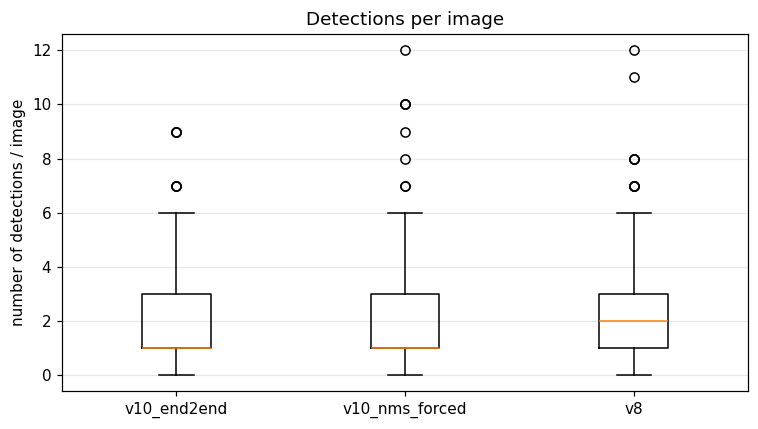

In [14]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.boxplot([dist['YOLOv10 end2end'][0], dist['YOLOv10 NMS forced'][0], dist['YOLOv8'][0]], labels=['v10_end2end', 'v10_nms_forced', 'v8'])
ax.set_title('Detections per image')
ax.set_ylabel('number of detections / image')
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(FIGS / f'detection_counts_{WEIGHT_KIND}.png', dpi=150)
plt.show()

## Per-Class Comparison

Overall metrics can hide class-specific weaknesses.
This chart helps identify whether a performance gap is broad across classes or concentrated on a few categories.

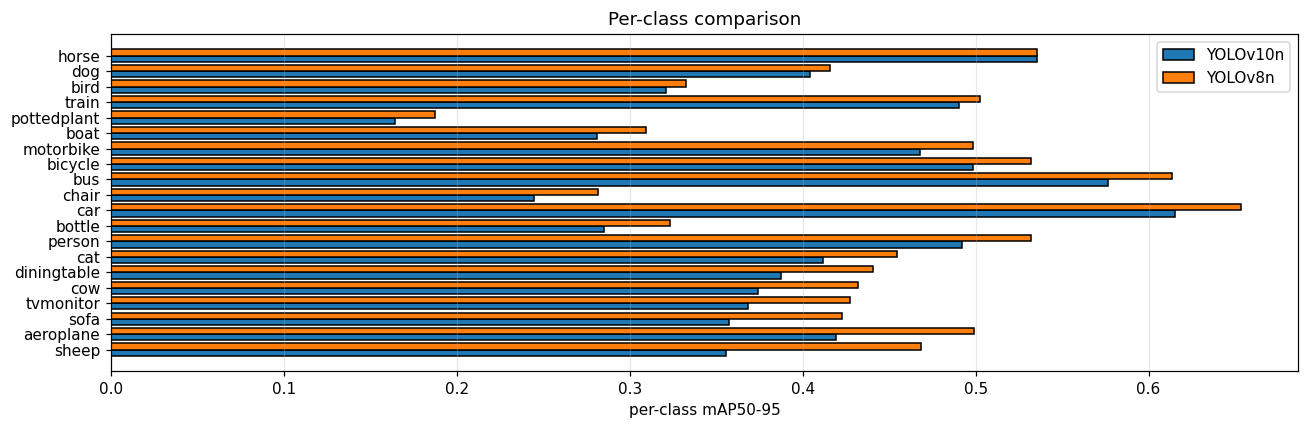

In [15]:
compare = pd.DataFrame({
    'class': list(eval_results['YOLOv10n']['per_class_map50_95'].keys()),
    'YOLOv10n': list(eval_results['YOLOv10n']['per_class_map50_95'].values()),
    'YOLOv8n': list(eval_results['YOLOv8n']['per_class_map50_95'].values()),
})
compare['gap'] = compare['YOLOv10n'] - compare['YOLOv8n']
compare = compare.sort_values('gap')

fig, ax = plt.subplots(figsize=(12, 4))
y = np.arange(len(compare))
ax.barh(y - 0.2, compare['YOLOv10n'], 0.4, label='YOLOv10n', edgecolor='black')
ax.barh(y + 0.2, compare['YOLOv8n'], 0.4, label='YOLOv8n', edgecolor='black')
ax.set_yticks(y)
ax.set_yticklabels(compare['class'])
ax.set_xlabel('per-class mAP50-95')
ax.set_title('Per-class comparison')
ax.grid(True, alpha=0.3, axis='x')
ax.legend()
plt.tight_layout()
plt.savefig(FIGS / f'per_class_{WEIGHT_KIND}.png', dpi=150)
plt.show()

## Qualitative Examples

These examples are useful to visually confirm the quantitative conclusions.
They help reveal missing detections, duplicate boxes, and confidence differences.

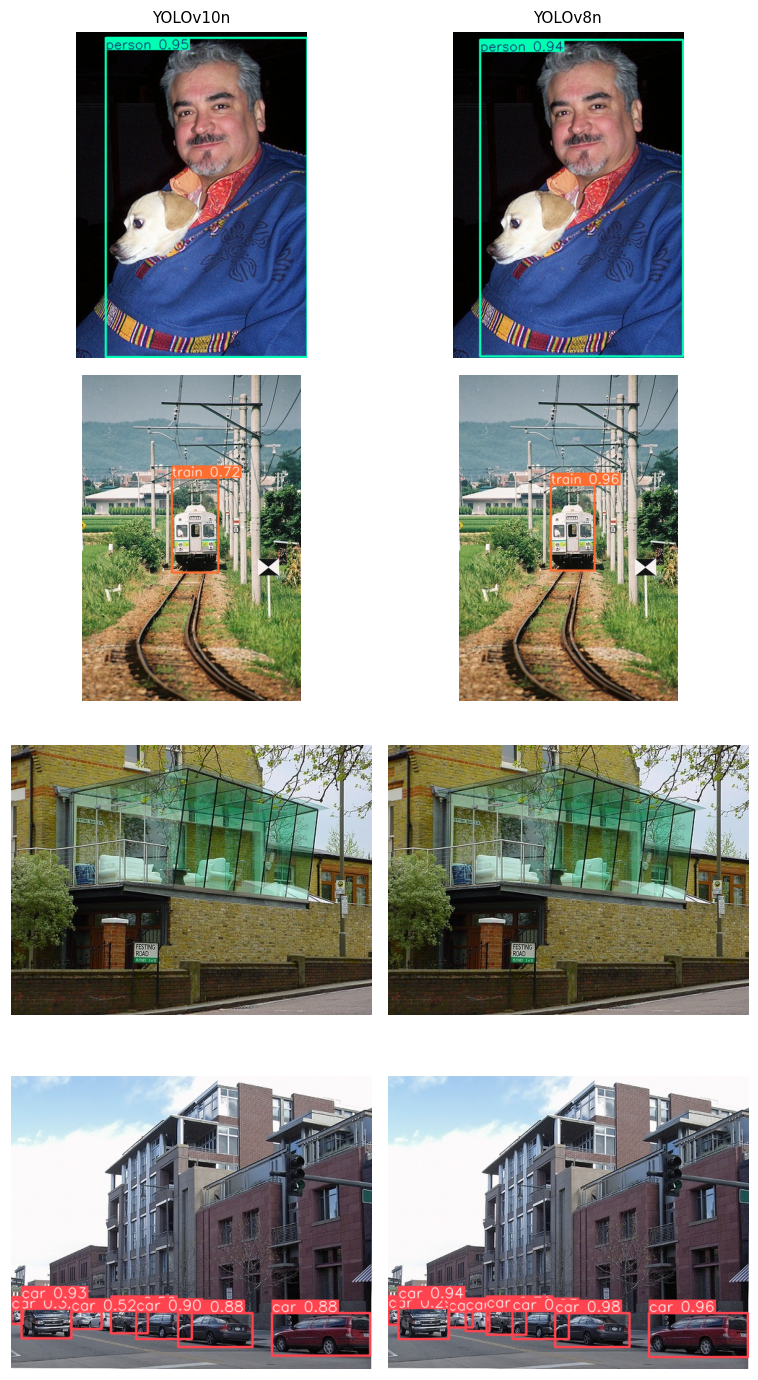

In [16]:
model_map = {'YOLOv10n': YOLO(get_weights(RUN_V10)), 'YOLOv8n': YOLO(get_weights(RUN_V8))}
img_paths = sorted(VAL_SAMPLE.glob('*.jpg'))[:4]
fig, axes = plt.subplots(len(img_paths), len(model_map), figsize=(7, 3.2 * len(img_paths)))
if len(img_paths) == 1:
    axes = np.array([axes])

for row_idx, img_path in enumerate(img_paths):
    for col_idx, (name, model) in enumerate(model_map.items()):
        result = model.predict(str(img_path), conf=0.25, imgsz=IMGSZ, device=DEVICE, verbose=False)[0]
        axes[row_idx, col_idx].imshow(cv2.cvtColor(result.plot(), cv2.COLOR_BGR2RGB))
        axes[row_idx, col_idx].set_title(name if row_idx == 0 else '', fontsize=10)
        axes[row_idx, col_idx].axis('off')

plt.tight_layout()
plt.savefig(FIGS / f'qualitative_grid_{WEIGHT_KIND}.png', dpi=130)
plt.show()

## Final Reading

A good reading order for the report is:

1. `mAP50-95` for the overall ranking.
2. `YOLOv10 end2end` vs `YOLOv10 NMS forced` for the paper-specific claim.
3. local latency and detection count for the efficiency side.
4. per-class and qualitative results for a more nuanced interpretation.

All figures are saved in `results/mps_runs/analysis_final/figures/`.